In [ ]:
# ===============================
# 1. IMPORTS
# ===============================
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

from torchvision import datasets, transforms, models
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score, roc_curve, auc

from torch.utils.data import DataLoader, Subset
import seaborn as sns
import numpy as np
import os
from sklearn.model_selection import train_test_split

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
# =========================================
# 2️⃣ TRANSFORMS
# =========================================
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(20),
    transforms.RandomAffine(degrees=15, translate=(0.05, 0.05), scale=(0.9, 1.1)),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.GaussianBlur(kernel_size=3),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.3),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

In [ ]:
# =========================================
# 3️⃣ DATASET PATH
# =========================================
from google.colab import drive
drive.mount('/content/drive')

data_dir = "/content/drive/MyDrive/parkinsons_dataset"

print("Folders:", os.listdir(data_dir))

# Load dataset WITHOUT transform (important!)
full_dataset = datasets.ImageFolder(data_dir)
class_names = full_dataset.classes
print("Classes:", class_names)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Folders: ['parkinson', 'normal']
Classes: ['normal', 'parkinson']


In [ ]:
# =========================================
# 4️⃣ PROPER SPLIT
# =========================================
indices = list(range(len(full_dataset)))
labels = [full_dataset.targets[i] for i in indices]

# First split: Train (80%) and Temp (20%)
train_idx, temp_idx = train_test_split(
    indices,
    test_size=0.2,
    stratify=labels,
    random_state=42
)

# Second split: Validation (10%) and Test (10%)
temp_labels = [labels[i] for i in temp_idx]

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.5,
    stratify=temp_labels,
    random_state=42
)

print("Train:", len(train_idx))
print("Validation:", len(val_idx))
print("Test:", len(test_idx))

Train: 664
Validation: 83
Test: 84


In [ ]:
# =========================================
# 5️⃣ CREATE SEPARATE DATASETS
# =========================================
train_dataset = Subset(
    datasets.ImageFolder(data_dir, transform=train_transform),
    train_idx
)

val_dataset = Subset(
    datasets.ImageFolder(data_dir, transform=val_test_transform),
    val_idx
)

test_dataset = Subset(
    datasets.ImageFolder(data_dir, transform=val_test_transform),
    test_idx
)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
# ===============================
# 6. MODEL FACTORY
# ===============================
def get_model(name, num_classes=2):
    if name == "cnn":
        model = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Flatten(),
            nn.Linear(64 * 56 * 56, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    elif name == "resnet18":
        model = models.resnet18(pretrained=True)
        model.fc = nn.Linear(model.fc.in_features, num_classes)

    elif name == "vgg16":
        model = models.vgg16(pretrained=True)
        model.classifier[6] = nn.Linear(4096, num_classes)

    elif name == "efficientnet":
        model = models.efficientnet_b0(pretrained=True)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)

    else:
        raise ValueError("Invalid model")

    return model


In [ ]:
# ===============================
# 4. TRAIN FUNCTION
# ===============================
def train_model(model, epochs=10):
    model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.0003)

    train_losses, val_losses = [], []

    for epoch in range(epochs):
        model.train()
        running_loss = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        train_losses.append(running_loss)

        # Validation
        model.eval()
        val_loss = 0
        correct = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()

                _, preds = torch.max(outputs, 1)
                correct += (preds == labels).sum().item()

        val_losses.append(val_loss)
        acc = correct / len(val_loader.dataset)

        print(f"Epoch {epoch+1}/{epochs} - Val Accuracy: {acc:.4f}")

    return model, train_losses, val_losses


In [ ]:
# ===============================
# 5. EVALUATION FUNCTION
# ===============================
def evaluate_model(model):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            y_true.extend(labels.numpy())
            y_pred.extend(preds.cpu().numpy())

    acc = accuracy_score(y_true, y_pred)
    report = classification_report(y_true, y_pred)

    return acc, report, y_true, y_pred

In [ ]:
# ===============================
# 6. ROC FUNCTION
# ===============================
def plot_roc(model, name):
    model.eval()
    y_true, y_scores = [], []

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)

            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)[:,1]

            y_true.extend(labels.numpy())
            y_scores.extend(probs.cpu().numpy())

    fpr, tpr, _ = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")
    plt.plot([0,1],[0,1],'--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {name}")
    plt.legend()
    plt.show()



Training CNN
Epoch 1/10 - Val Accuracy: 0.7349
Epoch 2/10 - Val Accuracy: 0.7349
Epoch 3/10 - Val Accuracy: 0.7349
Epoch 4/10 - Val Accuracy: 0.7108
Epoch 5/10 - Val Accuracy: 0.7349
Epoch 6/10 - Val Accuracy: 0.8675
Epoch 7/10 - Val Accuracy: 0.8916
Epoch 8/10 - Val Accuracy: 0.8795
Epoch 9/10 - Val Accuracy: 0.8675
Epoch 10/10 - Val Accuracy: 0.8795

cnn Accuracy: 0.8795
              precision    recall  f1-score   support

           0       0.87      0.98      0.92        61
           1       0.93      0.59      0.72        22

    accuracy                           0.88        83
   macro avg       0.90      0.79      0.82        83
weighted avg       0.89      0.88      0.87        83



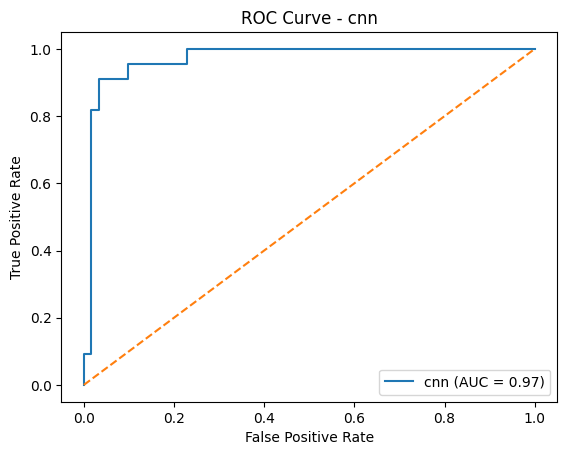


Training RESNET18


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1/10 - Val Accuracy: 0.9157
Epoch 2/10 - Val Accuracy: 0.9759
Epoch 3/10 - Val Accuracy: 0.8916
Epoch 4/10 - Val Accuracy: 0.9880
Epoch 5/10 - Val Accuracy: 1.0000
Epoch 6/10 - Val Accuracy: 0.9518
Epoch 7/10 - Val Accuracy: 0.9880
Epoch 8/10 - Val Accuracy: 1.0000
Epoch 9/10 - Val Accuracy: 1.0000
Epoch 10/10 - Val Accuracy: 0.9759

resnet18 Accuracy: 0.9759
              precision    recall  f1-score   support

           0       0.97      1.00      0.98        61
           1       1.00      0.91      0.95        22

    accuracy                           0.98        83
   macro avg       0.98      0.95      0.97        83
weighted avg       0.98      0.98      0.98        83



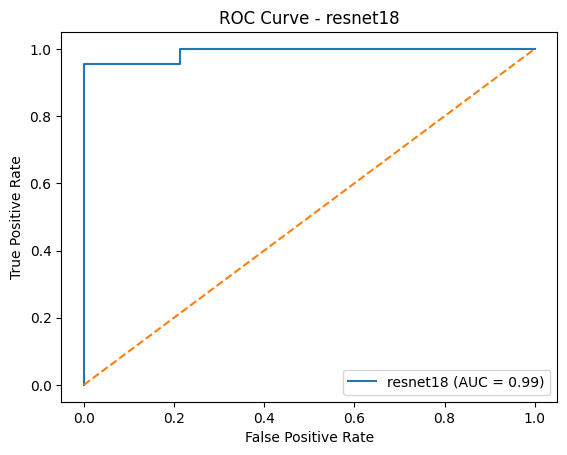


Training VGG16


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:03<00:00, 158MB/s]


Epoch 1/10 - Val Accuracy: 0.7349
Epoch 2/10 - Val Accuracy: 0.8193
Epoch 3/10 - Val Accuracy: 0.9036
Epoch 4/10 - Val Accuracy: 0.9880
Epoch 5/10 - Val Accuracy: 0.9639
Epoch 6/10 - Val Accuracy: 0.9880
Epoch 7/10 - Val Accuracy: 0.9639
Epoch 8/10 - Val Accuracy: 0.9880
Epoch 9/10 - Val Accuracy: 0.9759
Epoch 10/10 - Val Accuracy: 0.8434

vgg16 Accuracy: 0.8434
              precision    recall  f1-score   support

           0       0.82      1.00      0.90        61
           1       1.00      0.41      0.58        22

    accuracy                           0.84        83
   macro avg       0.91      0.70      0.74        83
weighted avg       0.87      0.84      0.82        83



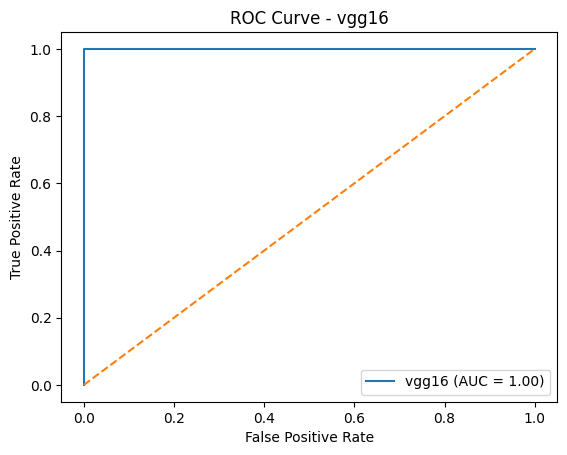

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



Training EFFICIENTNET
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 162MB/s]


Epoch 1/10 - Val Accuracy: 0.9639
Epoch 2/10 - Val Accuracy: 0.9759
Epoch 3/10 - Val Accuracy: 1.0000
Epoch 4/10 - Val Accuracy: 1.0000
Epoch 5/10 - Val Accuracy: 1.0000
Epoch 6/10 - Val Accuracy: 1.0000
Epoch 7/10 - Val Accuracy: 1.0000
Epoch 8/10 - Val Accuracy: 1.0000
Epoch 9/10 - Val Accuracy: 1.0000
Epoch 10/10 - Val Accuracy: 0.9759

efficientnet Accuracy: 0.9759
              precision    recall  f1-score   support

           0       1.00      0.97      0.98        61
           1       0.92      1.00      0.96        22

    accuracy                           0.98        83
   macro avg       0.96      0.98      0.97        83
weighted avg       0.98      0.98      0.98        83



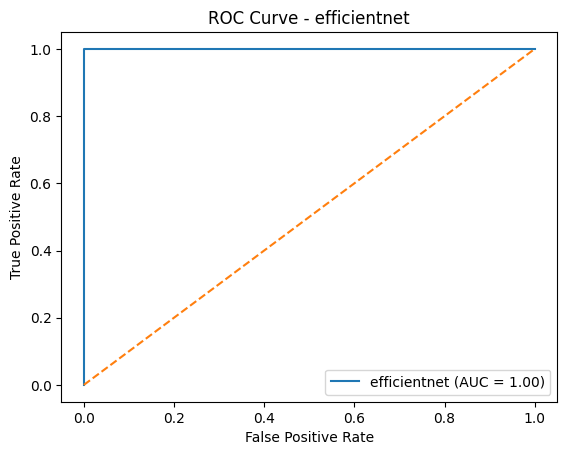

In [ ]:
# ===============================
# 7. TRAIN ALL MODELS
# ===============================
model_names = ["cnn", "resnet18", "vgg16", "efficientnet"]
results = {}

for name in model_names:
    print("\n==============================")
    print(f"Training {name.upper()}")
    print("==============================")

    model = get_model(name)

    model, train_loss, val_loss = train_model(model)

    acc, report, y_true, y_pred = evaluate_model(model)

    results[name] = acc

    print(f"\n{name} Accuracy: {acc:.4f}")
    print(report)

    plot_roc(model, name)

Confusion Matrix for CNN



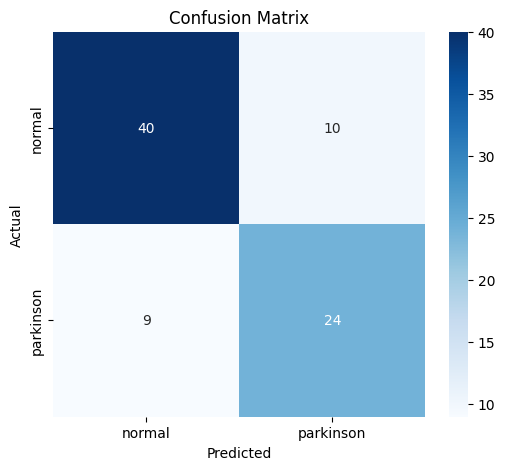


Confusion Matrix for RESNET18



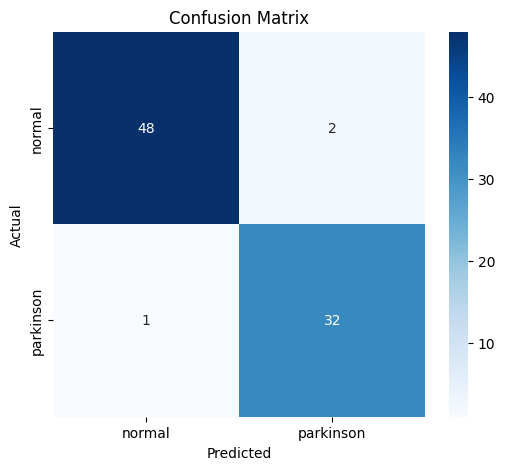


Confusion Matrix for VGG16



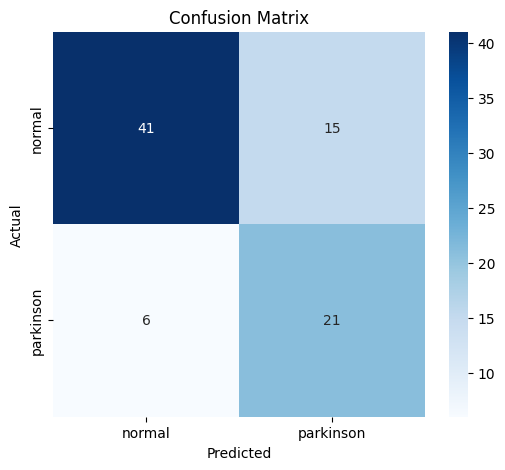


Confusion Matrix for EFFICIENTNET



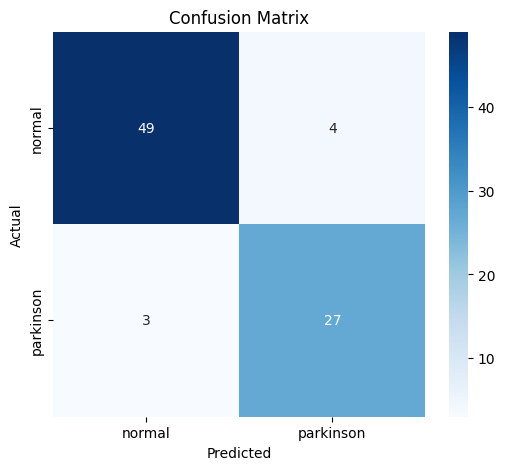

In [ ]:
def plot_confusion_matrix(model, dataloader, class_names):
    model = model.to(device)
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            y_true.extend(labels.numpy())
            y_pred.extend(preds.cpu().numpy())

    # Compute confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    # Display
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

    plt.figure()
    disp.plot(cmap='Blues')
    plt.title("Confusion Matrix")
    plt.show()

    return cm

model_names = ["cnn", "resnet18", "vgg16", "efficientnet"]

for name in model_names:
    print(f"\nConfusion Matrix for {name.upper()}")
    model = get_model(name)  # store models during training
    plot_confusion_matrix(model, val_loader, class_names)


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

def evaluate_on_test(model, test_loader):
    model = model.to(device)
    model.eval()

    y_true, y_pred = [], []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            y_true.extend(labels.numpy())
            y_pred.extend(preds.cpu().numpy())

    acc = accuracy_score(y_true, y_pred)
    report = classification_report(y_true, y_pred)

    return acc, report

In [ ]:
test_results = {}

for name in model_names:
    print(f"\n===== Testing {name.upper()} =====")

    model = get_model(name)  # make sure you saved models

    acc, report = evaluate_on_test(model, test_loader)

    test_results[name] = acc

    print(f"{name} Test Accuracy: {acc:.4f}")
    print(report)


===== Testing CNN =====
cnn Test Accuracy: 0.6548
              precision    recall  f1-score   support

           0       0.71      0.89      0.79        62
           1       0.00      0.00      0.00        22

    accuracy                           0.65        84
   macro avg       0.36      0.44      0.40        84
weighted avg       0.53      0.65      0.58        84


===== Testing RESNET18 =====


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


resnet18 Test Accuracy: 0.2738
              precision    recall  f1-score   support

           0       0.57      0.06      0.12        62
           1       0.25      0.86      0.38        22

    accuracy                           0.27        84
   macro avg       0.41      0.46      0.25        84
weighted avg       0.49      0.27      0.19        84


===== Testing VGG16 =====


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


vgg16 Test Accuracy: 0.4762
              precision    recall  f1-score   support

           0       0.70      0.52      0.59        62
           1       0.21      0.36      0.27        22

    accuracy                           0.48        84
   macro avg       0.45      0.44      0.43        84
weighted avg       0.57      0.48      0.51        84


===== Testing EFFICIENTNET =====


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


efficientnet Test Accuracy: 0.2619
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        62
           1       0.26      1.00      0.42        22

    accuracy                           0.26        84
   macro avg       0.13      0.50      0.21        84
weighted avg       0.07      0.26      0.11        84



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


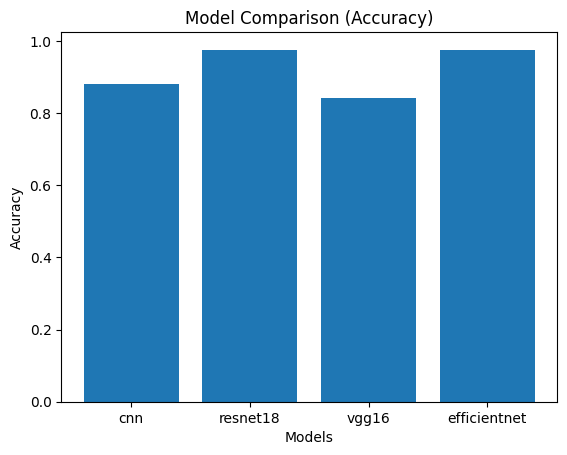

In [ ]:
# ===============================
# 8. ACCURACY COMPARISON GRAPH
# ===============================
plt.figure()
plt.bar(results.keys(), results.values())
plt.title("Model Comparison (Accuracy)")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.show()

In [ ]:
# =========================================
# 1️⃣ REPRODUCIBILITY FUNCTION
# =========================================
import random

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def run_reproducibility_experiment(model_name, seeds, epochs=10):
    results = []

    for seed in seeds:
        print(f"\nRunning {model_name} with seed {seed}")

        # Set seed
        set_seed(seed)

        # Initialize model
        model = get_model(model_name)

        # Train
        model, _, _ = train_model(model, epochs)

        # Evaluate
        acc, _, _, _ = evaluate_model(model)

        print(f"Seed {seed} Accuracy: {acc:.4f}")

        results.append(acc)

    return results

In [ ]:
seeds = [42, 7, 21, 100, 123]

all_results = {}

for model_name in ["cnn", "resnet18", "vgg16", "efficientnet"]:
    print(f"\n===== {model_name.upper()} REPRODUCIBILITY =====")

    acc_list = run_reproducibility_experiment(model_name, seeds)

    all_results[model_name] = acc_list


===== CNN REPRODUCIBILITY =====

Running cnn with seed 42
Epoch 1/10 - Val Accuracy: 0.7349
Epoch 2/10 - Val Accuracy: 0.7831
Epoch 3/10 - Val Accuracy: 0.9157
Epoch 4/10 - Val Accuracy: 0.8193
Epoch 5/10 - Val Accuracy: 0.8554
Epoch 6/10 - Val Accuracy: 0.8313
Epoch 7/10 - Val Accuracy: 0.8072
Epoch 8/10 - Val Accuracy: 0.9036
Epoch 9/10 - Val Accuracy: 0.9518
Epoch 10/10 - Val Accuracy: 0.9518
Seed 42 Accuracy: 0.9518

Running cnn with seed 7
Epoch 1/10 - Val Accuracy: 0.7349
Epoch 2/10 - Val Accuracy: 0.7470
Epoch 3/10 - Val Accuracy: 0.7590
Epoch 4/10 - Val Accuracy: 0.8795
Epoch 5/10 - Val Accuracy: 0.9277
Epoch 6/10 - Val Accuracy: 0.9518
Epoch 7/10 - Val Accuracy: 0.8554
Epoch 8/10 - Val Accuracy: 0.8193
Epoch 9/10 - Val Accuracy: 0.9518
Epoch 10/10 - Val Accuracy: 0.9277
Seed 7 Accuracy: 0.9277

Running cnn with seed 21
Epoch 1/10 - Val Accuracy: 0.2651
Epoch 2/10 - Val Accuracy: 0.7349
Epoch 3/10 - Val Accuracy: 0.7349
Epoch 4/10 - Val Accuracy: 0.7470
Epoch 5/10 - Val Accura

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1/10 - Val Accuracy: 0.9518
Epoch 2/10 - Val Accuracy: 0.8675
Epoch 3/10 - Val Accuracy: 0.9639
Epoch 4/10 - Val Accuracy: 0.9518
Epoch 5/10 - Val Accuracy: 1.0000
Epoch 6/10 - Val Accuracy: 1.0000
Epoch 7/10 - Val Accuracy: 1.0000
Epoch 8/10 - Val Accuracy: 0.9880
Epoch 9/10 - Val Accuracy: 0.9880
Epoch 10/10 - Val Accuracy: 1.0000
Seed 42 Accuracy: 1.0000

Running resnet18 with seed 7


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1/10 - Val Accuracy: 0.8916
Epoch 2/10 - Val Accuracy: 0.8916
Epoch 3/10 - Val Accuracy: 0.9518
Epoch 4/10 - Val Accuracy: 0.9518
Epoch 5/10 - Val Accuracy: 0.9759
Epoch 6/10 - Val Accuracy: 0.9759
Epoch 7/10 - Val Accuracy: 1.0000
Epoch 8/10 - Val Accuracy: 0.9880
Epoch 9/10 - Val Accuracy: 0.9518
Epoch 10/10 - Val Accuracy: 1.0000
Seed 7 Accuracy: 1.0000

Running resnet18 with seed 21


...

Epoch 1/10 - Val Accuracy: 0.7952
Epoch 2/10 - Val Accuracy: 0.9036
Epoch 3/10 - Val Accuracy: 0.9759
Epoch 4/10 - Val Accuracy: 0.9880
Epoch 5/10 - Val Accuracy: 1.0000
Epoch 6/10 - Val Accuracy: 0.9880
Epoch 7/10 - Val Accuracy: 0.9880
Epoch 8/10 - Val Accuracy: 1.0000
Epoch 9/10 - Val Accuracy: 0.9880
Epoch 10/10 - Val Accuracy: 0.9880
Seed 21 Accuracy: 0.9880

Running efficientnet with seed 100


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1/10 - Val Accuracy: 0.8554
Epoch 2/10 - Val Accuracy: 0.9880
Epoch 3/10 - Val Accuracy: 0.9880
Epoch 4/10 - Val Accuracy: 1.0000
Epoch 5/10 - Val Accuracy: 1.0000
Epoch 6/10 - Val Accuracy: 1.0000
Epoch 7/10 - Val Accuracy: 0.9880
Epoch 8/10 - Val Accuracy: 0.9880
Epoch 9/10 - Val Accuracy: 0.9880
Epoch 10/10 - Val Accuracy: 0.9880
Seed 100 Accuracy: 0.9880

Running efficientnet with seed 123


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1/10 - Val Accuracy: 0.9518
Epoch 2/10 - Val Accuracy: 0.9518
Epoch 3/10 - Val Accuracy: 1.0000
Epoch 4/10 - Val Accuracy: 1.0000
Epoch 5/10 - Val Accuracy: 0.9880
Epoch 6/10 - Val Accuracy: 1.0000
Epoch 7/10 - Val Accuracy: 1.0000
Epoch 8/10 - Val Accuracy: 1.0000
Epoch 9/10 - Val Accuracy: 1.0000
Epoch 10/10 - Val Accuracy: 0.9880
Seed 123 Accuracy: 0.9880


In [ ]:
def analyze_results(results):
    import numpy as np

    for model, accs in results.items():
        mean = np.mean(accs)
        std = np.std(accs)

        print(f"\n{model.upper()}")
        print(f"Accuracies: {accs}")
        print(f"Mean Accuracy: {mean:.4f}")
        print(f"Std Deviation: {std:.4f}")

In [ ]:
analyze_results(all_results)


CNN
Accuracies: [0.9518072289156626, 0.927710843373494, 0.7590361445783133, 0.8554216867469879, 0.9036144578313253]
Mean Accuracy: 0.8795
Std Deviation: 0.0682

RESNET18
Accuracies: [1.0, 1.0, 1.0, 0.963855421686747, 0.9879518072289156]
Mean Accuracy: 0.9904
Std Deviation: 0.0141

VGG16
Accuracies: [0.9879518072289156, 0.9759036144578314, 0.9397590361445783, 1.0, 0.9156626506024096]
Mean Accuracy: 0.9639
Std Deviation: 0.0314

EFFICIENTNET
Accuracies: [0.9879518072289156, 1.0, 0.9879518072289156, 0.9879518072289156, 0.9879518072289156]
Mean Accuracy: 0.9904
Std Deviation: 0.0048


/tmp/ipykernel_711/2288852461.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(all_results.values(), labels=all_results.keys())


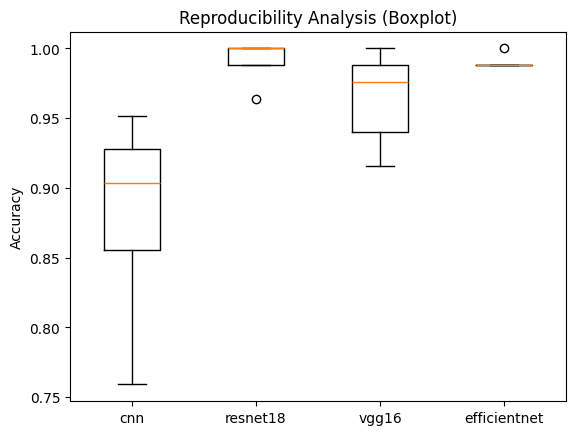

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.boxplot(all_results.values(), labels=all_results.keys())
plt.title("Reproducibility Analysis (Boxplot)")
plt.ylabel("Accuracy")
plt.show()

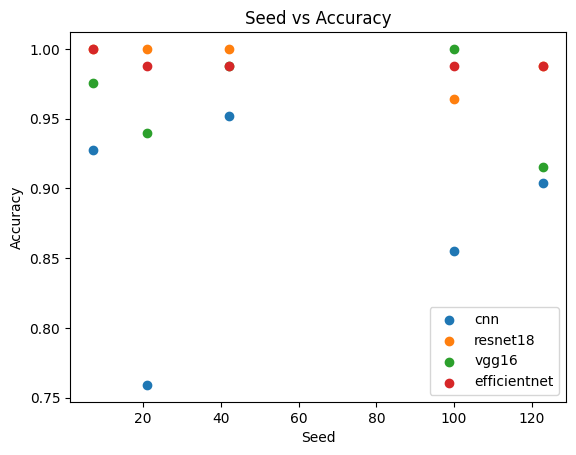

In [ ]:
for model, accs in all_results.items():
    plt.scatter(seeds, accs, label=model)

plt.legend()
plt.xlabel("Seed")
plt.ylabel("Accuracy")
plt.title("Seed vs Accuracy")
plt.show()

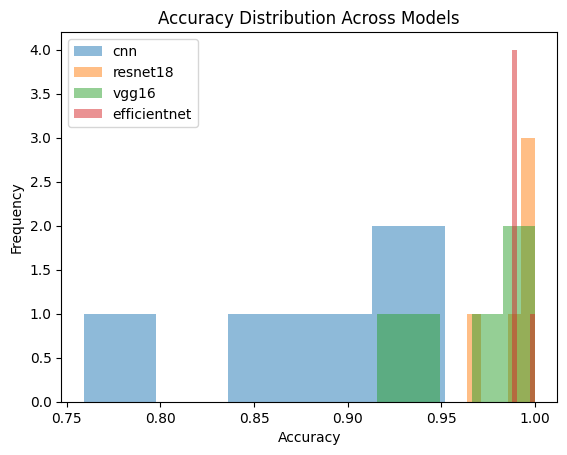

In [ ]:
import matplotlib.pyplot as plt

def plot_accuracy_distribution(all_results):
    plt.figure()

    for model, accs in all_results.items():
        plt.hist(accs, alpha=0.5, bins=5, label=model)

    plt.xlabel("Accuracy")
    plt.ylabel("Frequency")
    plt.title("Accuracy Distribution Across Models")
    plt.legend()
    plt.show()

plot_accuracy_distribution(all_results)

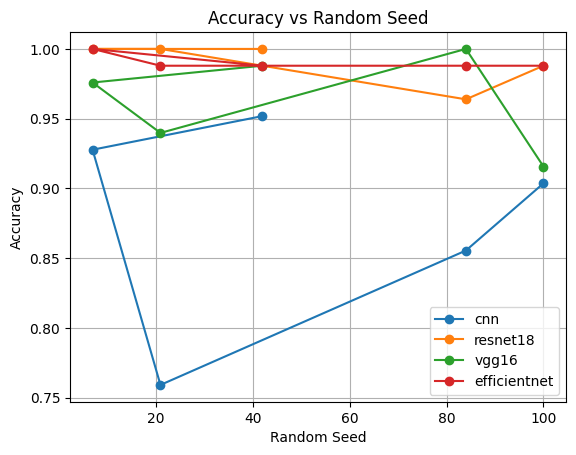

In [ ]:
import matplotlib.pyplot as plt

def plot_accuracy_vs_seed(all_results, seeds):
    plt.figure()

    for model, accs in all_results.items():
        plt.plot(seeds, accs, marker='o', label=model)

    plt.xlabel("Random Seed")
    plt.ylabel("Accuracy")
    plt.title("Accuracy vs Random Seed")
    plt.legend()
    plt.grid()
    plt.show()

plot_accuracy_vs_seed(all_results, seeds)
